In [ ]:
"""
PixelForge — Conditional GAN for Pixel Art Sprite Generation
=============================================================
v2 — WGAN-GP edition, fixes discriminator collapse seen in v1.

Key changes from v1:
  - LOSS_MODE switched to "wgan-gp" by default
  - D_STEPS increased to 5 (standard for WGAN-GP)
  - Discriminator: BatchNorm replaced with InstanceNorm (required for WGAN-GP)
  - Discriminator: no final Sigmoid — outputs raw critic score
  - Adam betas changed to (0.0, 0.9) per WGAN-GP paper
  - IMG_CHANNELS auto-detected from dataset
  - LR scheduler halves LR at halfway point
  - Gradient clipping on generator
  - SAVE_EVERY = 5 for more granular visual tracking
  - Wasserstein distance logged — should decrease as training improves

Requirements:
    pip install torch torchvision pillow tqdm

Usage:
    python train.py
"""

import os
import json
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image
from tqdm import tqdm

# ═══════════════════════════════════════════════════════════════════
#  CONFIG  ← only section you need to edit
# ═══════════════════════════════════════════════════════════════════

DATA_DIR    = "/content/drive/MyDrive/dataset"   # parent folder containing front/back/left/right
OUTPUT_DIR  = "/content/drive/MyDrive/dataset_output_final"        # where samples and checkpoints are saved

# Training
NUM_EPOCHS  = 400          # more epochs — WGAN-GP trains stably for longer
BATCH_SIZE  = 64
LR_G        = 0.0001       # WGAN-GP paper recommends 1e-4
LR_D        = 0.0001
BETA1       = 0.0          # WGAN-GP paper: β1=0 (not 0.5)
BETA2       = 0.9          # WGAN-GP paper: β2=0.9 (not 0.999)

# Architecture
NOISE_DIM   = 100
NUM_CLASSES = 4            # front / back / left / right
IMG_SIZE    = 64

# WGAN-GP
GP_LAMBDA   = 10           # gradient penalty weight
D_STEPS     = 5            # critic updates per generator update

# LR schedule: decay LR by this factor at the halfway epoch
LR_DECAY_FACTOR = 0.5

# Logging
SAVE_EVERY  = 5            # save sample grid every N epochs
CKPT_EVERY  = 25           # save checkpoint every N epochs

SEED        = 42

# ═══════════════════════════════════════════════════════════════════


def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# ───────────────────────────────────────────────────────────────────
#  DATASET
# ───────────────────────────────────────────────────────────────────

def get_dataloader(data_dir, batch_size, img_size):
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])
    dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    print(f"Class mapping : {dataset.class_to_idx}")
    print(f"Total images  : {len(dataset)}")

    # Auto-detect channels from first image so script works for both RGB and RGBA
    sample_img, _ = dataset[0]
    img_channels = sample_img.shape[0]
    print(f"Image channels: {img_channels}")

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        drop_last=True,
    )
    return loader, dataset.class_to_idx, img_channels


# ───────────────────────────────────────────────────────────────────
#  GENERATOR
# ───────────────────────────────────────────────────────────────────

class Generator(nn.Module):
    def __init__(self, noise_dim, num_classes, img_channels):
        super().__init__()
        self.input_dim = noise_dim + num_classes

        self.project = nn.Sequential(
            nn.Linear(self.input_dim, 512 * 4 * 4, bias=False),
            nn.BatchNorm1d(512 * 4 * 4),
            nn.ReLU(inplace=True),
        )

        self.conv_blocks = nn.Sequential(
            # 4 → 8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # 8 → 16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            # 16 → 32
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            # 32 → 64
            nn.ConvTranspose2d(64, img_channels, 4, 2, 1, bias=False),
            nn.Sigmoid(),   # [0,1] output — correct for pixel art
        )

    def forward(self, noise, labels_onehot):
        x = torch.cat([noise, labels_onehot], dim=1)
        x = self.project(x)
        x = x.view(x.size(0), 512, 4, 4)
        return self.conv_blocks(x)


# ───────────────────────────────────────────────────────────────────
#  DISCRIMINATOR (critic)
# ───────────────────────────────────────────────────────────────────
# BatchNorm is REMOVED. It creates batch-level correlations that break
# the WGAN-GP gradient penalty. InstanceNorm is used instead — it
# normalizes per-image, not per-batch, so the penalty stays valid.
# ───────────────────────────────────────────────────────────────────

class Discriminator(nn.Module):
    def __init__(self, num_classes, img_channels, img_size):
        super().__init__()
        self.img_size = img_size
        self.embed = nn.Embedding(num_classes, img_size * img_size)
        in_channels = img_channels + 1

        self.conv_blocks = nn.Sequential(
            # 64 → 32  (no norm on first layer — standard practice)
            nn.Conv2d(in_channels, 64, 4, 2, 1, bias=True),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 → 16
            nn.Conv2d(64, 128, 4, 2, 1, bias=True),
            nn.InstanceNorm2d(128, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 → 8
            nn.Conv2d(128, 256, 4, 2, 1, bias=True),
            nn.InstanceNorm2d(256, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # 8 → 4
            nn.Conv2d(256, 512, 4, 2, 1, bias=True),
            nn.InstanceNorm2d(512, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Raw score output — no Sigmoid for WGAN-GP
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1),
        )

    def forward(self, img, labels):
        label_map = self.embed(labels).view(
            labels.size(0), 1, self.img_size, self.img_size
        )
        x = torch.cat([img, label_map], dim=1)
        return self.classifier(self.conv_blocks(x))


# ───────────────────────────────────────────────────────────────────
#  WEIGHT INIT
# ───────────────────────────────────────────────────────────────────

def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


# ───────────────────────────────────────────────────────────────────
#  GRADIENT PENALTY
# ───────────────────────────────────────────────────────────────────

def gradient_penalty(D, real_imgs, fake_imgs, labels, device):
    B     = real_imgs.size(0)
    alpha = torch.rand(B, 1, 1, 1, device=device)
    interpolated = (alpha * real_imgs + (1 - alpha) * fake_imgs).requires_grad_(True)
    d_interp = D(interpolated, labels)
    gradients = torch.autograd.grad(
        outputs=d_interp,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interp),
        create_graph=True,
        retain_graph=True,
    )[0]
    gradients = gradients.view(B, -1)
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()


# ───────────────────────────────────────────────────────────────────
#  HELPERS
# ───────────────────────────────────────────────────────────────────

def to_onehot(labels, num_classes, device):
    onehot = torch.zeros(labels.size(0), num_classes, device=device)
    onehot.scatter_(1, labels.unsqueeze(1), 1.0)
    return onehot


def make_fixed_noise(noise_dim, num_classes, n_per_class, device):
    noise_list, label_list = [], []
    for cls in range(num_classes):
        noise_list.append(torch.randn(n_per_class, noise_dim, device=device))
        label_list.append(
            torch.full((n_per_class,), cls, dtype=torch.long, device=device)
        )
    return torch.cat(noise_list), torch.cat(label_list)


# ───────────────────────────────────────────────────────────────────
#  TRAINING LOOP
# ───────────────────────────────────────────────────────────────────

def train():
    set_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    out = Path(OUTPUT_DIR)
    samples_dir = out / "samples"
    ckpt_dir    = out / "checkpoints"
    samples_dir.mkdir(parents=True, exist_ok=True)
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    # ── Data ──
    loader, class_to_idx, img_channels = get_dataloader(DATA_DIR, BATCH_SIZE, IMG_SIZE)

    # ── Models ──
    G = Generator(NOISE_DIM, NUM_CLASSES, img_channels).to(device)
    D = Discriminator(NUM_CLASSES, img_channels, IMG_SIZE).to(device)
    G.apply(weights_init)
    D.apply(weights_init)

    print(f"Generator     params: {sum(p.numel() for p in G.parameters()):,}")
    print(f"Discriminator params: {sum(p.numel() for p in D.parameters()):,}")

    # ── Optimizers ──
    opt_G = optim.Adam(G.parameters(), lr=LR_G, betas=(BETA1, BETA2))
    opt_D = optim.Adam(D.parameters(), lr=LR_D, betas=(BETA1, BETA2))

    # LR halved at the halfway point
    half = NUM_EPOCHS // 2
    sched_G = optim.lr_scheduler.MultiStepLR(opt_G, milestones=[half], gamma=LR_DECAY_FACTOR)
    sched_D = optim.lr_scheduler.MultiStepLR(opt_D, milestones=[half], gamma=LR_DECAY_FACTOR)

    # ── Fixed samples for visual tracking ──
    N_PER_CLASS  = 8
    fixed_noise, fixed_labels = make_fixed_noise(NOISE_DIM, NUM_CLASSES, N_PER_CLASS, device)
    fixed_onehot = to_onehot(fixed_labels, NUM_CLASSES, device)

    log = {"epoch": [], "critic_loss": [], "gen_loss": [], "w_distance": []}
    start_time = time.time()

    for epoch in range(1, NUM_EPOCHS + 1):
        G.train(); D.train()
        epoch_loss_D = epoch_loss_G = epoch_w_dist = 0.0
        n_batches = 0

        for real_imgs, labels in tqdm(loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}", leave=False):
            real_imgs = real_imgs.to(device)
            labels    = labels.to(device)
            B         = real_imgs.size(0)

            # ── Critic (D) steps ─────────────────────────────────
            for _ in range(D_STEPS):
                opt_D.zero_grad()

                noise       = torch.randn(B, NOISE_DIM, device=device)
                fake_labels = torch.randint(0, NUM_CLASSES, (B,), device=device)
                fake_onehot = to_onehot(fake_labels, NUM_CLASSES, device)

                with torch.no_grad():
                    fake_imgs = G(noise, fake_onehot)

                real_scores = D(real_imgs, labels)
                fake_scores = D(fake_imgs.detach(), fake_labels)
                gp          = gradient_penalty(D, real_imgs, fake_imgs.detach(),
                                               labels, device)

                loss_D = fake_scores.mean() - real_scores.mean() + GP_LAMBDA * gp
                loss_D.backward()
                opt_D.step()

            w_dist = (real_scores.mean() - fake_scores.mean()).item()

            # ── Generator step ───────────────────────────────────
            opt_G.zero_grad()

            noise       = torch.randn(B, NOISE_DIM, device=device)
            fake_labels = torch.randint(0, NUM_CLASSES, (B,), device=device)
            fake_onehot = to_onehot(fake_labels, NUM_CLASSES, device)
            fake_imgs   = G(noise, fake_onehot)
            fake_scores = D(fake_imgs, fake_labels)

            loss_G = -fake_scores.mean()
            loss_G.backward()
            nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
            opt_G.step()

            epoch_loss_D += loss_D.item()
            epoch_loss_G += loss_G.item()
            epoch_w_dist += w_dist
            n_batches    += 1

        sched_G.step()
        sched_D.step()

        avg_loss_D = epoch_loss_D / n_batches
        avg_loss_G = epoch_loss_G / n_batches
        avg_w_dist = epoch_w_dist / n_batches
        elapsed    = time.time() - start_time

        # Wasserstein distance should trend negative then slowly improve toward 0
        print(f"Epoch {epoch:>4}/{NUM_EPOCHS}  |  "
              f"Critic: {avg_loss_D:+.4f}  |  "
              f"Gen: {avg_loss_G:+.4f}  |  "
              f"W-dist: {avg_w_dist:+.4f}  |  "
              f"Elapsed: {elapsed/60:.1f}m")

        # ── Sample grid ──
        if epoch % SAVE_EVERY == 0 or epoch == 1:
            G.eval()
            with torch.no_grad():
                samples = G(fixed_noise, fixed_onehot)
            save_image(
                samples,
                samples_dir / f"epoch_{epoch:04d}.png",
                nrow=N_PER_CLASS,
                normalize=False,
            )
            G.train()

        # ── Checkpoint ──
        if epoch % CKPT_EVERY == 0:
            torch.save({
                "epoch":        epoch,
                "G_state_dict": G.state_dict(),
                "D_state_dict": D.state_dict(),
                "opt_G":        opt_G.state_dict(),
                "opt_D":        opt_D.state_dict(),
                "critic_loss":  avg_loss_D,
                "gen_loss":     avg_loss_G,
                "class_to_idx": class_to_idx,
                "img_channels": img_channels,
                "noise_dim":    NOISE_DIM,
            }, ckpt_dir / f"ckpt_epoch_{epoch:04d}.pt")

        log["epoch"].append(epoch)
        log["critic_loss"].append(avg_loss_D)
        log["gen_loss"].append(avg_loss_G)
        log["w_distance"].append(avg_w_dist)

    # ── Final save ──
    torch.save({
        "epoch":        NUM_EPOCHS,
        "G_state_dict": G.state_dict(),
        "D_state_dict": D.state_dict(),
        "class_to_idx": class_to_idx,
        "img_channels": img_channels,
        "noise_dim":    NOISE_DIM,
        "num_classes":  NUM_CLASSES,
        "img_size":     IMG_SIZE,
    }, out / "pixelforge_final.pt")

    with open(out / "training_log.json", "w") as f:
        json.dump(log, f, indent=2)

    print(f"\nTraining complete.")
    print(f"Model   → {out / 'pixelforge_final.pt'}")
    print(f"Samples → {samples_dir}")


if __name__ == "__main__":
    train()

Using device: cuda
Class mapping : {'back': 0, 'front': 1, 'left': 2, 'right': 3}
Total images  : 3648
Image channels: 3
Generator     params: 3,624,832
Discriminator params: 2,783,937


Epoch 1/400:   0%|          | 0/57 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch    1/400  |  Critic: -69.2784  |  Gen: +47.8304  |  W-dist: +93.7587  |  Elapsed: 10.5m


Epoch    2/400  |  Critic: -49.8320  |  Gen: +43.4286  |  W-dist: +70.4980  |  Elapsed: 10.6m


Epoch    3/400  |  Critic: -28.7361  |  Gen: +40.4008  |  W-dist: +38.1396  |  Elapsed: 10.8m


...

Epoch  396/400  |  Critic: -7.0811  |  Gen: +166.4257  |  W-dist: +7.8768  |  Elapsed: 69.7m


Epoch  397/400  |  Critic: -6.5951  |  Gen: +166.6214  |  W-dist: +7.3961  |  Elapsed: 69.8m


Epoch  398/400  |  Critic: -4.8753  |  Gen: +164.7535  |  W-dist: +5.6941  |  Elapsed: 70.0m


Epoch  399/400  |  Critic: -6.6356  |  Gen: +164.3292  |  W-dist: +7.3963  |  Elapsed: 70.1m


Epoch  400/400  |  Critic: -5.7165  |  Gen: +164.8236  |  W-dist: +6.5841  |  Elapsed: 70.3m

Training complete.
Model   → /content/drive/MyDrive/dataset_output_final/pixelforge_final.pt
Samples → /content/drive/MyDrive/dataset_output_final/samples


Loading log from: /content/drive/MyDrive/dataset_output_v4 (final)/training_log.json


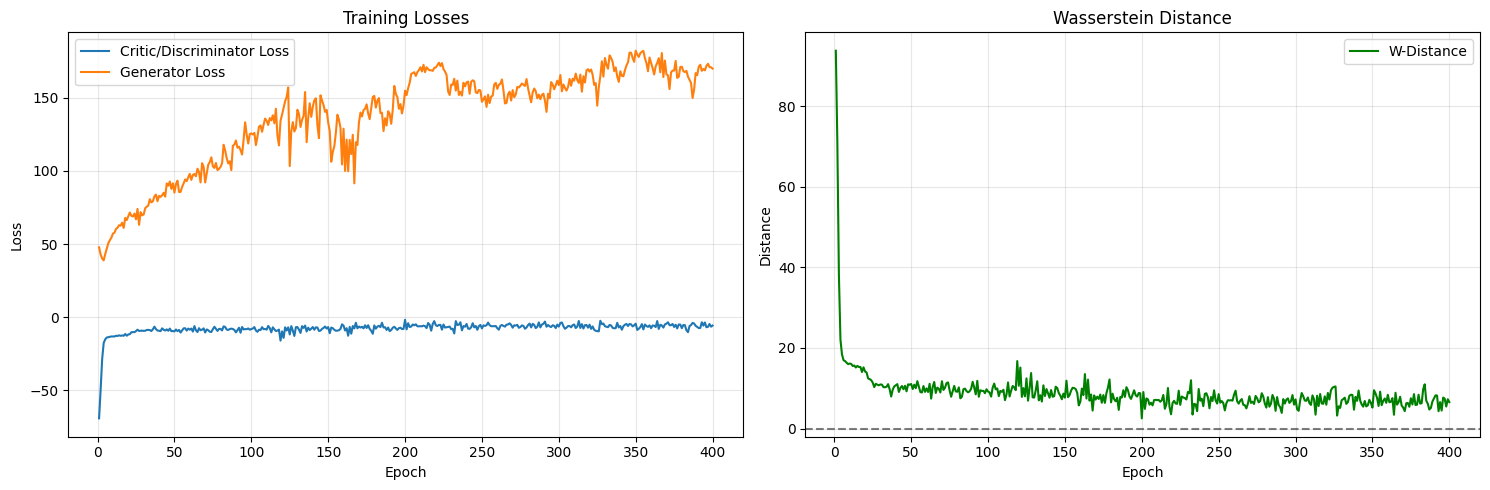

In [ ]:
import matplotlib.pyplot as plt
import json
import os
import glob

# Re-initializing necessary variables for independent execution
# The file list shows 'dataset_output_v4 (final)' with a space.
POSSIBLE_PATHS = [
    "/content/drive/MyDrive/dataset_output_v4 (final)/training_log.json",
    "/content/drive/MyDrive/dataset_output_final/training_log.json"
]

log_path = None
for p in POSSIBLE_PATHS:
    if os.path.exists(p):
        log_path = p
        break

# Fallback: search for any training_log.json in MyDrive if primary paths fail
if not log_path:
    search_results = glob.glob('/content/drive/MyDrive/**/training_log.json', recursive=True)
    if search_results:
        log_path = search_results[0]

if log_path and os.path.exists(log_path):
    print(f'Loading log from: {log_path}')
    with open(log_path, 'r') as f:
        log = json.load(f)

    epochs = log['epoch']
    plt.figure(figsize=(15, 5))

    # Plot 1: Loss Curves
    plt.subplot(1, 2, 1)
    critic_loss = log.get('critic_loss', log.get('loss_D', []))
    gen_loss = log.get('gen_loss', log.get('loss_G', []))

    plt.plot(epochs, critic_loss, label='Critic/Discriminator Loss')
    plt.plot(epochs, gen_loss, label='Generator Loss')
    plt.title('Training Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Wasserstein Distance
    if 'w_distance' in log:
        plt.subplot(1, 2, 2)
        plt.plot(epochs, log['w_distance'], color='green', label='W-Distance')
        plt.axhline(0, color='black', linestyle='--', alpha=0.5)
        plt.title('Wasserstein Distance')
        plt.xlabel('Epoch')
        plt.ylabel('Distance')
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('Log file still not found. Please ensure your Google Drive is mounted.')
    print('You can mount it using: from google.colab import drive; drive.mount("/content/drive")')


Evaluating Model from Epoch: 400


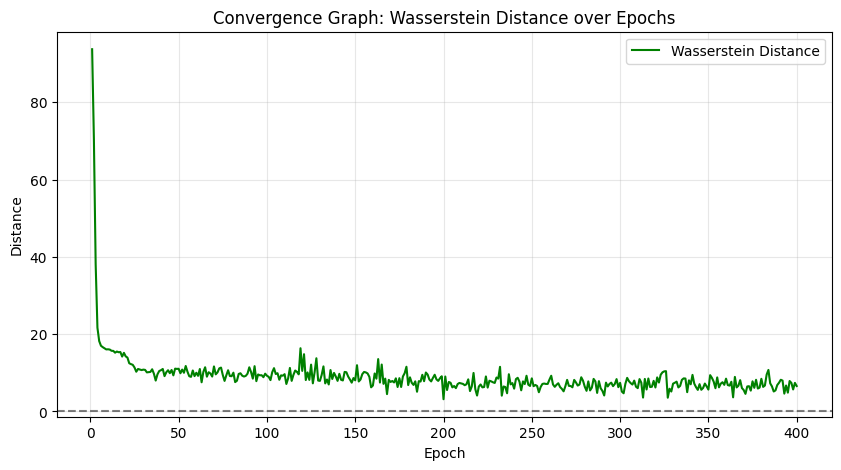

Final Wasserstein Distance: 6.5841
Note: A lower W-Distance generally indicates a 'better' match to real data distribution.


In [ ]:
import torch
import matplotlib.pyplot as plt
import json
import os

def calculate_pixel_consistency(model_path, log_path, data_dir, device='cuda'):
    # Load model checkpoint
    checkpoint = torch.load(model_path, map_location=device)
    print(f"Evaluating Model from Epoch: {checkpoint.get('epoch', 'unknown')}")

    # Load and Plot Training Log
    if os.path.exists(log_path):
        with open(log_path, 'r') as f:
            log = json.load(f)

        epochs = log.get('epoch', [])
        w_dist = log.get('w_distance', [])

        if epochs and w_dist:
            plt.figure(figsize=(10, 5))
            plt.plot(epochs, w_dist, color='green', label='Wasserstein Distance')
            plt.axhline(0, color='black', linestyle='--', alpha=0.5)
            plt.title('Convergence Graph: Wasserstein Distance over Epochs')
            plt.xlabel('Epoch')
            plt.ylabel('Distance')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()

            final_w = w_dist[-1]
            print(f"Final Wasserstein Distance: {final_w:.4f}")
            print("Note: A lower W-Distance generally indicates a 'better' match to real data distribution.")
    else:
        print("Log file not found. Could not generate graph.")

# Paths
MODEL_PATH = '/content/drive/MyDrive/dataset_output_final/pixelforge_final.pt'
LOG_PATH = '/content/drive/MyDrive/dataset_output_final/training_log.json'
DATA_DIR = '/content/drive/MyDrive/dataset'

calculate_pixel_consistency(MODEL_PATH, LOG_PATH, DATA_DIR)

In [ ]:
"""
PixelForge GUI — Character Angle Explorer
Generates a character at all 4 view angles and lets you SLERP between them
with a rotation slider.
"""

import math
import os
import gradio as gr
import numpy as np
import torch
import torch.nn as nn
from PIL import Image

# ─── config ───
CHECKPOINT_PATH = "/content/drive/MyDrive/dataset_output_final/pixelforge_final.pt"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ANGLE_ORDER = ["front", "left", "back", "right"]
ANGLE_LABELS = {
    "front": "FRONT",
    "left":  "LEFT",
    "back":  "BACK",
    "right": "RIGHT",
}

# ─── model definition ───
class Generator(nn.Module):
    def __init__(self, noise_dim, num_classes, img_channels=3, img_size=64):
        super().__init__()
        self.noise_dim = noise_dim
        self.num_classes = num_classes
        self.input_dim = noise_dim + num_classes
        self.project = nn.Sequential(
            nn.Linear(self.input_dim, 512 * 4 * 4, bias=False),
            nn.BatchNorm1d(512 * 4 * 4),
            nn.ReLU(inplace=True),
        )
        self.conv_blocks = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, img_channels, 4, 2, 1, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, noise, labels_onehot):
        x = torch.cat([noise, labels_onehot], dim=1)
        x = self.project(x).view(-1, 512, 4, 4)
        return self.conv_blocks(x)

def load_model(path):
    ckpt = torch.load(path, map_location=DEVICE)
    meta = {
        "noise_dim": ckpt.get("noise_dim", 100),
        "num_classes": ckpt.get("num_classes", 4),
        "img_channels": ckpt.get("img_channels", 3),
        "img_size": ckpt.get("img_size", 64),
        "class_to_idx": ckpt.get("class_to_idx", {'back': 0, 'front': 1, 'left': 2, 'right': 3}),
    }
    G = Generator(meta["noise_dim"], meta["num_classes"], meta["img_channels"], meta["img_size"]).to(DEVICE)
    G.load_state_dict(ckpt["G_state_dict"])
    G.eval()
    return G, meta

G_MODEL, META = load_model(CHECKPOINT_PATH)
CLASS_TO_IDX = META["class_to_idx"]

def to_onehot(idx, num_classes):
    onehot = torch.zeros(1, num_classes, device=DEVICE)
    onehot[0, idx] = 1.0
    return onehot

def make_noise(seed, noise_dim):
    gen = torch.Generator(device='cpu')
    gen.manual_seed(int(seed))
    return torch.randn(1, noise_dim, generator=gen).to(DEVICE)

def to_pil(tensor, upscale=4):
    arr = (tensor.detach().cpu().permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)
    img = Image.fromarray(arr)
    w, h = img.size
    return img.resize((w * upscale, h * upscale), Image.NEAREST)

def get_thumbs(char_num):
    char_num = int(char_num)
    nd = META["noise_dim"]
    z = make_noise(char_num, nd)
    thumbs = []
    for angle in ANGLE_ORDER:
        oh = to_onehot(CLASS_TO_IDX[angle], META["num_classes"])
        with torch.no_grad():
            out = G_MODEL(z, oh).squeeze(0)
        thumbs.append(to_pil(out, upscale=3))
    return thumbs

def get_main_image(char_num, slider_val):
    char_num = int(char_num)
    slider_val = float(slider_val)
    nd = META["noise_dim"]
    z = make_noise(char_num, nd)

    # Interpolate the condition vectors (one-hot labels) for smooth rotation,
    # keeping the latent noise (character identity) identical.
    seg = min(int(slider_val // 100), 2)
    t = (slider_val % 100) / 100.0
    a1, a2 = ANGLE_ORDER[seg], ANGLE_ORDER[seg+1]

    oh1 = to_onehot(CLASS_TO_IDX[a1], META["num_classes"])
    oh2 = to_onehot(CLASS_TO_IDX[a2], META["num_classes"])
    oh_interp = (1 - t) * oh1 + t * oh2

    with torch.no_grad():
        main_out = G_MODEL(z, oh_interp).squeeze(0)

    main_img = to_pil(main_out, upscale=5)
    target_angle = a1 if t < 0.5 else a2
    cur_label = ANGLE_LABELS[target_angle]
    return main_img, cur_label

def update_all(char_num, slider_val):
    thumbs = get_thumbs(char_num)
    main_img, cur_label = get_main_image(char_num, slider_val)
    return main_img, thumbs[0], thumbs[1], thumbs[2], thumbs[3], cur_label

CSS = """body, .gradio-container { background:#1a1a2e !important; color:#e0e0e0 !important; } .gr-image img { image-rendering:pixelated !important; }"""

with gr.Blocks(css=CSS) as demo:
    gr.HTML("<h1 style='text-align:center;color:#f5c400'>PIXEL FORGE EXPLORER</h1>")
    with gr.Row():
        char_num = gr.Number(label="CHARACTER SEED", value=0, precision=0)
        load_btn = gr.Button("GENERATE", variant="primary")
    angle_label = gr.Textbox(label="CURRENT VIEW", interactive=False)
    main_image = gr.Image(label="SPRITE", type="pil", height=350)
    rotation_slider = gr.Slider(minimum=0, maximum=300, step=1, value=0, label="ROTATION (Front -> Left -> Back -> Right)")
    with gr.Row():
        t1 = gr.Image(label="FRONT", type="pil", height=150)
        t2 = gr.Image(label="LEFT", type="pil", height=150)
        t3 = gr.Image(label="BACK", type="pil", height=150)
        t4 = gr.Image(label="RIGHT", type="pil", height=150)

    # show_progress=False prevents the loading screen overlay from blocking the UI during slider drags
    load_btn.click(update_all, inputs=[char_num, rotation_slider], outputs=[main_image, t1, t2, t3, t4, angle_label], show_progress=False)
    rotation_slider.change(get_main_image, inputs=[char_num, rotation_slider], outputs=[main_image, angle_label], show_progress=False)

if __name__ == '__main__':
    demo.launch(share=True)


/tmp/ipykernel_23548/2893608468.py:131: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=CSS) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a4efdccf19e5c10bde.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import torch
import numpy as np
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm

def calculate_consistency_score(num_samples=100):
    G.eval()
    nd = ckpt['noise_dim']
    nc = ckpt['num_classes']
    scores = []

    print(f'Calculating Visual Consistency (SSIM) across {num_samples} characters...')

    with torch.no_grad():
        for _ in tqdm(range(num_samples)):
            # Generate one character (fixed noise)
            z = torch.randn(1, nd, device=DEVICE)

            # Generate all 4 views
            views = []
            for i in range(nc):
                oh = torch.zeros(1, nc, device=DEVICE)
                oh[0, i] = 1.0
                img = G(z, oh).squeeze(0).cpu().permute(1, 2, 0).numpy()
                views.append(img)

            # Calculate pairwise SSIM between all views
            char_scores = []
            for i in range(len(views)):
                for j in range(i + 1, len(views)):
                    # channel_axis=2 for RGB images
                    s = ssim(views[i], views[j], data_range=1.0, channel_axis=2)
                    char_scores.append(s)

            scores.append(np.mean(char_scores))

    final_score = np.mean(scores)
    print(f'\nMean Inter-View Consistency (SSIM): {final_score:.4f}')
    print('Interpretation: 1.0 = Perfectly identical views, >0.4 = Strong identity preservation in pixel art.')

calculate_consistency_score(num_samples=100)

Calculating Visual Consistency (SSIM) across 100 characters...


100%|██████████| 100/100 [00:00<00:00, 100.80it/s]


Mean Inter-View Consistency (SSIM): 0.6636
Interpretation: 1.0 = Perfectly identical views, >0.4 = Strong identity preservation in pixel art.
